<a href="https://colab.research.google.com/github/naikwadesharvil/mental-health-detection-nlp/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# Install required libraries
!pip install transformers datasets torch scikit-learn
!pip install lime shap wandb
!pip install pandas numpy matplotlib seaborn
!pip install nltk emoji contractions wordcloud joblib

print("All libraries installed successfully!")

All libraries installed successfully!


In [27]:
import torch

print("🔍 Checking GPU Availability...")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Device Count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("\n✅ Setup verification complete!")

Checking GPU Availability...
CUDA Available: True
CUDA Device Count: 1
GPU Name: Tesla T4
GPU Memory: 15.64 GB

 Setup verification complete!


In [53]:
import os, re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Create folders
for p in ["data/raw", "results/figures", "results/metrics", "models"]:
    os.makedirs(p, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Imports done | Device:", device)

✅ Imports done | Device: cuda


In [54]:
url = "https://raw.githubusercontent.com/laxmimerit/twitter-suicidal-intention-dataset/master/twitter-suicidal_data.csv"
df = pd.read_csv(url)
df = df.rename(columns={"intention": "label"})

# sanity check
assert "tweet" in df.columns and "label" in df.columns, df.columns

print("✅ Dataset loaded:", df.shape)
print(df.columns)

# save local copy (reproducibility)
df.to_csv("data/raw/twitter_suicidal_data.csv", index=False)
print("✅ Saved local copy to data/raw/twitter_suicidal_data.csv")

df.head()

✅ Dataset loaded: (9119, 2)
Index(['tweet', 'label'], dtype='object')
✅ Saved local copy to data/raw/twitter_suicidal_data.csv


,tweet,label
0,my life is meaningless i just want to end my l...,1
1,muttering i wanna die to myself daily for a fe...,1
2,work slave i really feel like my only purpose ...,1
3,i did something on the 2 of october i overdose...,1
4,i feel like no one cares i just want to die ma...,1


Missing values:
 tweet    0
label    0
dtype: int64


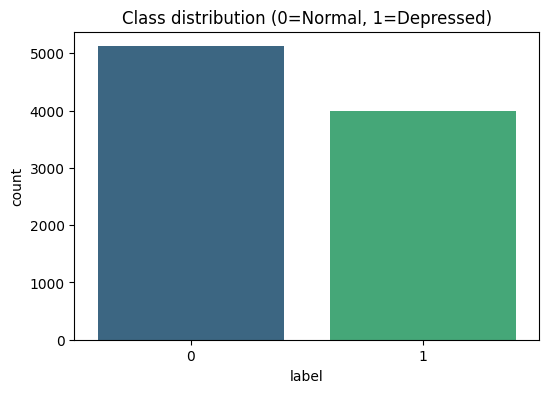

Normal Posts: 56.16%
Depressed Posts: 43.84%


In [55]:
print("Missing values:\n", df.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("Class distribution (0=Normal, 1=Depressed)")
plt.show()

normal_pct = (df["label"] == 0).mean() * 100
dep_pct = (df["label"] == 1).mean() * 100
print(f"Normal Posts: {normal_pct:.2f}%")
print(f"Depressed Posts: {dep_pct:.2f}%")

In [56]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download("wordnet")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text_baseline(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\@\w+", "", text)          # remove @mentions
    text = re.sub(r"#", "", text)              # remove '#' but keep the word
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["tweet"].apply(clean_text_baseline)
df[["tweet", "clean_text", "label"]].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tweet,clean_text,label
0,my life is meaningless i just want to end my l...,life meaningless want end life badly life comp...,1
1,muttering i wanna die to myself daily for a fe...,muttering wanna die daily month feel worthless...,1
2,work slave i really feel like my only purpose ...,work slave really feel like purpose life make ...,1
3,i did something on the 2 of october i overdose...,something october overdosed felt alone horribl...,1
4,i feel like no one cares i just want to die ma...,feel like one care want die maybe feel less lo...,1


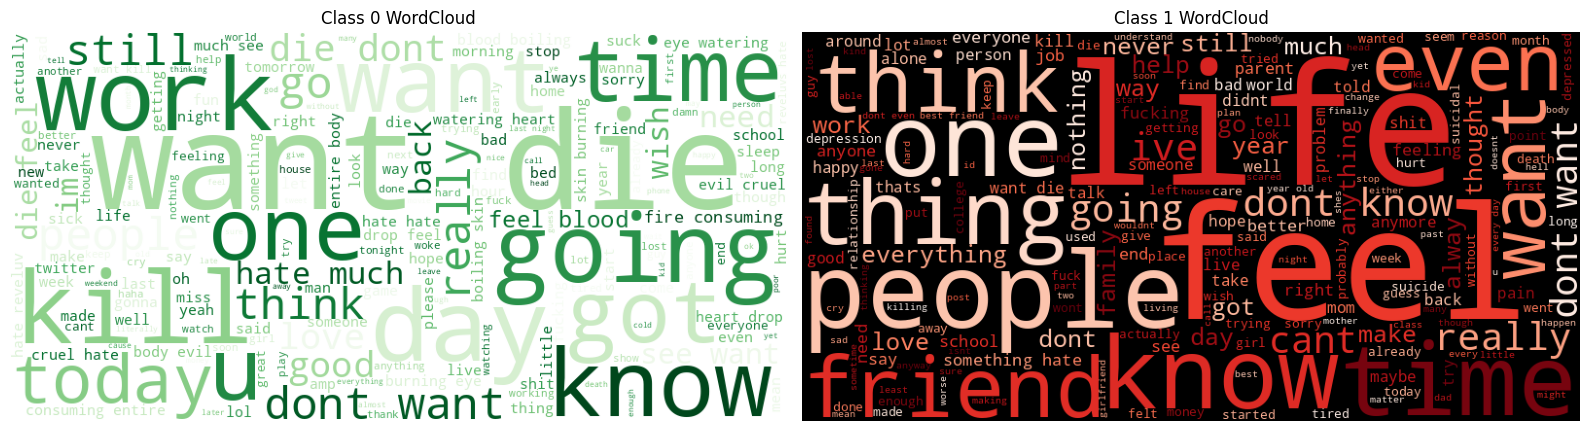

In [57]:
from wordcloud import WordCloud

normal_text = " ".join(df.loc[df["label"]==0, "clean_text"].fillna("").tolist())
depressed_text = " ".join(df.loc[df["label"]==1, "clean_text"].fillna("").tolist())

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
wc1 = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(normal_text if normal_text.strip() else "empty")
plt.imshow(wc1); plt.axis("off"); plt.title("Class 0 WordCloud")

plt.subplot(1,2,2)
wc2 = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(depressed_text if depressed_text.strip() else "empty")
plt.imshow(wc2); plt.axis("off"); plt.title("Class 1 WordCloud")

plt.tight_layout()
plt.show()

In [58]:
from sklearn.model_selection import train_test_split

X_base = df["clean_text"].fillna("")
y = df["label"].astype(int)

X_train_base, X_temp_base, y_train_base, y_temp_base = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)
X_val_base, X_test_base, y_val_base, y_test_base = train_test_split(
    X_temp_base, y_temp_base, test_size=0.5, random_state=42, stratify=y_temp_base
)

print("Baseline split sizes:",
      len(X_train_base), len(X_val_base), len(X_test_base))

Baseline split sizes: 7295 912 912


=== TF-IDF + Logistic Regression (VAL) ===
              precision    recall  f1-score   support

           0     0.8727    0.9238    0.8975       512
           1     0.8946    0.8275    0.8597       400

    accuracy                         0.8816       912
   macro avg     0.8836    0.8757    0.8786       912
weighted avg     0.8823    0.8816    0.8810       912

VAL ROC-AUC: 0.95531494140625


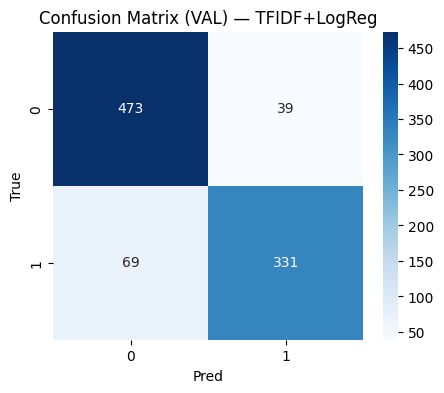

=== TF-IDF + Logistic Regression (TEST) ===
              precision    recall  f1-score   support

           0     0.9011    0.9434    0.9218       512
           1     0.9229    0.8675    0.8943       400

    accuracy                         0.9101       912
   macro avg     0.9120    0.9054    0.9080       912
weighted avg     0.9107    0.9101    0.9097       912

TEST ROC-AUC: 0.9704443359375001
✅ Saved baseline artifacts to models/ and results/metrics/


{'model': 'tfidf_logreg',
 'val_roc_auc': 0.95531494140625,
 'test_roc_auc': 0.9704443359375001}

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train_base)
X_val_vec   = tfidf.transform(X_val_base)

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_vec, y_train_base)

val_pred = clf.predict(X_val_vec)
val_prob = clf.predict_proba(X_val_vec)[:,1]

print("=== TF-IDF + Logistic Regression (VAL) ===")
print(classification_report(y_val_base, val_pred, digits=4))
print("VAL ROC-AUC:", roc_auc_score(y_val_base, val_prob))

cm = confusion_matrix(y_val_base, val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (VAL) — TFIDF+LogReg")
plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

# Test
X_test_vec = tfidf.transform(X_test_base)
test_pred  = clf.predict(X_test_vec)
test_prob  = clf.predict_proba(X_test_vec)[:,1]
print("=== TF-IDF + Logistic Regression (TEST) ===")
print(classification_report(y_test_base, test_pred, digits=4))
print("TEST ROC-AUC:", roc_auc_score(y_test_base, test_prob))

# Save artifacts
joblib.dump(tfidf, "models/tfidf_vectorizer.joblib")
joblib.dump(clf, "models/logreg_tfidf.joblib")

metrics_base = {
    "model": "tfidf_logreg",
    "val_roc_auc": float(roc_auc_score(y_val_base, val_prob)),
    "test_roc_auc": float(roc_auc_score(y_test_base, test_prob)),
}
with open("results/metrics/tfidf_logreg_metrics.json", "w") as f:
    json.dump(metrics_base, f, indent=2)

print("✅ Saved baseline artifacts to models/ and results/metrics/")
metrics_base

In [60]:
def clean_text_lstm(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_lstm"] = df["tweet"].apply(clean_text_lstm)

X_lstm = df["text_lstm"].fillna("")
y = df["label"].astype(int)

X_train_lstm, X_temp_lstm, y_train_lstm, y_temp_lstm = train_test_split(
    X_lstm, y, test_size=0.2, random_state=42, stratify=y
)
X_val_lstm, X_test_lstm, y_val_lstm, y_test_lstm = train_test_split(
    X_temp_lstm, y_temp_lstm, test_size=0.5, random_state=42, stratify=y_temp_lstm
)

print("LSTM split sizes:",
      len(X_train_lstm), len(X_val_lstm), len(X_test_lstm))

LSTM split sizes: 7295 912 912


In [61]:
from collections import Counter

def tokenize_simple(text):
    return re.findall(r"[a-z']+", text.lower())

counter = Counter()
for t in X_train_lstm.tolist():
    counter.update(tokenize_simple(t))

MAX_VOCAB = 30000
PAD, UNK = "<PAD>", "<UNK>"
word2id = {PAD: 0, UNK: 1}
for w, _ in counter.most_common(MAX_VOCAB - 2):
    if w not in word2id:
        word2id[w] = len(word2id)

vocab_size = len(word2id)
MAX_LEN = 100

def text_to_ids(text):
    tokens = tokenize_simple(text)
    ids = [word2id.get(w, word2id[UNK]) for w in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [word2id[PAD]] * (MAX_LEN - len(ids))
    return ids

X_train_ids = np.array([text_to_ids(t) for t in X_train_lstm.tolist()], dtype=np.int64)
X_val_ids   = np.array([text_to_ids(t) for t in X_val_lstm.tolist()], dtype=np.int64)
X_test_ids  = np.array([text_to_ids(t) for t in X_test_lstm.tolist()], dtype=np.int64)

y_train_np = y_train_lstm.values.astype(np.int64)
y_val_np   = y_val_lstm.values.astype(np.int64)
y_test_np  = y_test_lstm.values.astype(np.int64)

print("✅ Vocab size:", vocab_size, "| X_train_ids:", X_train_ids.shape)

✅ Vocab size: 21252 | X_train_ids: (7295, 100)


In [62]:
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, X_ids, y):
        self.X = torch.tensor(X_ids, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(TextDataset(X_train_ids, y_train_np), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val_ids, y_val_np), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(X_test_ids, y_test_np), batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoaders ready")

✅ DataLoaders ready


In [65]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h, c) = self.lstm(emb)
        h_forward = h[-2]
        h_backward = h[-1]
        h_cat = torch.cat([h_forward, h_backward], dim=1)
        x = self.dropout(h_cat)
        logits = self.fc(x).squeeze(1)
        return logits

model = LSTMClassifier(vocab_size).to(device)
print(model)

LSTMClassifier(
  (embedding): Embedding(21252, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [66]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

def predict_probs(loader):
    model.eval()
    probs_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            probs_all.append(probs.cpu().numpy())
            y_all.append(yb.cpu().numpy())
    probs_all = np.concatenate(probs_all)
    y_all = np.concatenate(y_all).astype(int)
    preds = (probs_all >= 0.5).astype(int)
    return y_all, preds, probs_all

EPOCHS = 5
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    val_y, val_pred, val_prob = predict_probs(val_loader)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {total_loss/len(train_loader):.4f} | Val F1: {f1_score(val_y, val_pred):.4f} | Val AUC: {roc_auc_score(val_y, val_prob):.4f}")

# Final VAL report
val_y, val_pred, val_prob = predict_probs(val_loader)
print("=== LSTM (VAL) ===")
print(classification_report(val_y, val_pred, digits=4))
print("VAL ROC-AUC:", roc_auc_score(val_y, val_prob))

# TEST
test_y, test_pred, test_prob = predict_probs(test_loader)
print("=== LSTM (TEST) ===")
print(classification_report(test_y, test_pred, digits=4))
print("TEST ROC-AUC:", roc_auc_score(test_y, test_prob))

# Save
torch.save(model.state_dict(), "models/lstm_model.pt")
with open("models/lstm_vocab.json", "w") as f:
    json.dump(word2id, f)

lstm_metrics = {
    "model": "lstm",
    "max_len": MAX_LEN,
    "vocab_size": vocab_size,
    "val_f1": float(f1_score(val_y, val_pred)),
    "val_roc_auc": float(roc_auc_score(val_y, val_prob)),
    "test_roc_auc": float(roc_auc_score(test_y, test_prob)),
}
with open("results/metrics/lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=2)

print("✅ Saved LSTM artifacts to models/ and results/metrics/")
lstm_metrics

Epoch 1/5 | Train Loss: 0.4442 | Val F1: 0.8079 | Val AUC: 0.8952
Epoch 2/5 | Train Loss: 0.2952 | Val F1: 0.8325 | Val AUC: 0.9182
Epoch 3/5 | Train Loss: 0.2191 | Val F1: 0.8340 | Val AUC: 0.9293
Epoch 4/5 | Train Loss: 0.1666 | Val F1: 0.8525 | Val AUC: 0.9433
Epoch 5/5 | Train Loss: 0.1071 | Val F1: 0.8425 | Val AUC: 0.9397
=== LSTM (VAL) ===
              precision    recall  f1-score   support

           0     0.8884    0.8555    0.8716       512
           1     0.8234    0.8625    0.8425       400

    accuracy                         0.8586       912
   macro avg     0.8559    0.8590    0.8571       912
weighted avg     0.8599    0.8586    0.8589       912

VAL ROC-AUC: 0.939677734375
=== LSTM (TEST) ===
              precision    recall  f1-score   support

           0     0.9141    0.8730    0.8931       512
           1     0.8463    0.8950    0.8700       400

    accuracy                         0.8827       912
   macro avg     0.8802    0.8840    0.8815       912
weig

{'model': 'lstm',
 'max_len': 100,
 'vocab_size': 21252,
 'val_f1': 0.8424908424908425,
 'val_roc_auc': 0.939677734375,
 'test_roc_auc': 0.9552148437500001}